# 13 - v4 vs v5 Result Shift and Label Artifact

## Research question

How did corrected v5 labels and decimation change conclusions relative to frozen v4?

## Artifact paths loaded

- `results/v5/headline_models/v4_vs_v5_comparison.csv`
- `results/v5/headline_models/v5_headline_model_comparison.csv`
- `results/v5/final_v5_model_comparison.csv`
- `results/v5/figures/v4_vs_v5_rmse_by_model.png`

All cells are analysis-only. No heavy training is run.


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown, Image
except Exception:
    def display(x): print(x)
    def Markdown(x): return x
    def Image(filename=None, **kwargs): return f"Image({filename})"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})
COLORS = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#0072B2", "#56B4E9", "#8C8C8C"]
OUR_COLOR = "#E76F51"
BASELINE_COLOR = "#B0BEC5"

def find_repo_root():
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "results" / "v5").exists() and (p / "reports" / "v5_campaign").exists():
            return p
    raise RuntimeError("Could not find repository root containing results/v5 and reports/v5_campaign")

ROOT = find_repo_root()
RESULTS = ROOT / "results" / "v5"
REPORTS = ROOT / "reports" / "v5_campaign"
FIGS = RESULTS / "figures"
missing_artifacts = []

def rel(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT)).replace("\\", "/")
    except Exception:
        return str(path).replace("\\", "/")

def artifact(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if not p.exists():
        missing_artifacts.append(rel(p))
    return p

def read_csv_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return pd.DataFrame()
    return pd.read_csv(p)

def read_json_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return {}
    with p.open("r", encoding="utf-8") as handle:
        return json.load(handle)

def show_artifact_status(paths):
    rows = []
    for item in paths:
        p = ROOT / item
        rows.append({"artifact": item, "exists": p.exists(), "bytes": p.stat().st_size if p.exists() else None})
        if not p.exists():
            missing_artifacts.append(item)
    display(pd.DataFrame(rows))

def show_missing():
    unique = sorted(set(missing_artifacts))
    if unique:
        display(Markdown("### Missing artifacts recorded by this notebook"))
        display(pd.DataFrame({"missing_artifact": unique}))
    else:
        display(Markdown("### Missing artifacts recorded by this notebook: none"))

def maybe_display_png(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        missing_artifacts.append(rel(p))
        display(Markdown(f"Existing figure not found: `{rel(p)}`"))

print("Repository root:", ROOT)


Repository root: D:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC


In [2]:
ARTIFACTS = [
    'results/v5/headline_models/v4_vs_v5_comparison.csv',
    'results/v5/headline_models/v5_headline_model_comparison.csv',
    'results/v5/final_v5_model_comparison.csv',
    'results/v5/figures/v4_vs_v5_rmse_by_model.png',
]
show_artifact_status(ARTIFACTS)

v4v5 = read_csv_safe("results/v5/headline_models/v4_vs_v5_comparison.csv")
headline = read_csv_safe("results/v5/headline_models/v5_headline_model_comparison.csv")
final = read_csv_safe("results/v5/final_v5_model_comparison.csv")


,artifact,exists,bytes
0,results/v5/headline_models/v4_vs_v5_comparison...,True,700
1,results/v5/headline_models/v5_headline_model_c...,True,2923
2,results/v5/final_v5_model_comparison.csv,True,5653
3,results/v5/figures/v4_vs_v5_rmse_by_model.png,True,31452


In [3]:
if not v4v5.empty:
    display(v4v5.sort_values(["scenario", "model"]).round(4))
    key = v4v5[v4v5["model"].isin(["hard_coulomb_lstm", "hard_coulomb_tcn", "null[ocv25_qnom]"])]
    display(Markdown("### HC-LSTM / HC-TCN / Null v4-v5 shift"))
    display(key.round(4))
else:
    display(Markdown("v4-v5 comparison unavailable."))


,model,scenario,v4_rmse_pct,v5c_rmse_pct,rmse_delta_pp,v4_maxe_pct,v5c_maxe_pct,v4_n20_rmse,v5c_n20_rmse
1,hard_coulomb_lstm,scenario_A,12.7107,11.0493,-1.6614,55.1126,46.1952,17.8587,16.7560
0,hard_coulomb_tcn,scenario_A,11.4592,10.9496,-0.5096,46.7303,43.2938,NaN,16.6462
3,null[ocv25_qnom],scenario_A,13.2436,13.0297,-0.2139,86.9666,60.9376,NaN,19.5747
4,vanilla+posthoc_clamp,scenario_A,25.5561,25.0261,-0.5300,NaN,46.8818,NaN,23.1923
2,vanilla_lstm,scenario_A,13.3712,11.5921,-1.7791,51.0242,46.8817,NaN,17.3787
7,hard_coulomb_lstm,scenario_B,8.5667,9.8729,1.3062,34.9985,35.3573,NaN,7.8601
6,null[ocv25_qnom],scenario_B,7.5572,7.5278,-0.0294,NaN,94.7159,NaN,14.3190
5,vanilla_lstm,scenario_B,7.2806,6.3485,-0.9321,NaN,50.6370,NaN,8.8031


### HC-LSTM / HC-TCN / Null v4-v5 shift

,model,scenario,v4_rmse_pct,v5c_rmse_pct,rmse_delta_pp,v4_maxe_pct,v5c_maxe_pct,v4_n20_rmse,v5c_n20_rmse
0,hard_coulomb_tcn,scenario_A,11.4592,10.9496,-0.5096,46.7303,43.2938,NaN,16.6462
1,hard_coulomb_lstm,scenario_A,12.7107,11.0493,-1.6614,55.1126,46.1952,17.8587,16.7560
3,null[ocv25_qnom],scenario_A,13.2436,13.0297,-0.2139,86.9666,60.9376,NaN,19.5747
6,null[ocv25_qnom],scenario_B,7.5572,7.5278,-0.0294,NaN,94.7159,NaN,14.3190
7,hard_coulomb_lstm,scenario_B,8.5667,9.8729,1.3062,34.9985,35.3573,NaN,7.8601


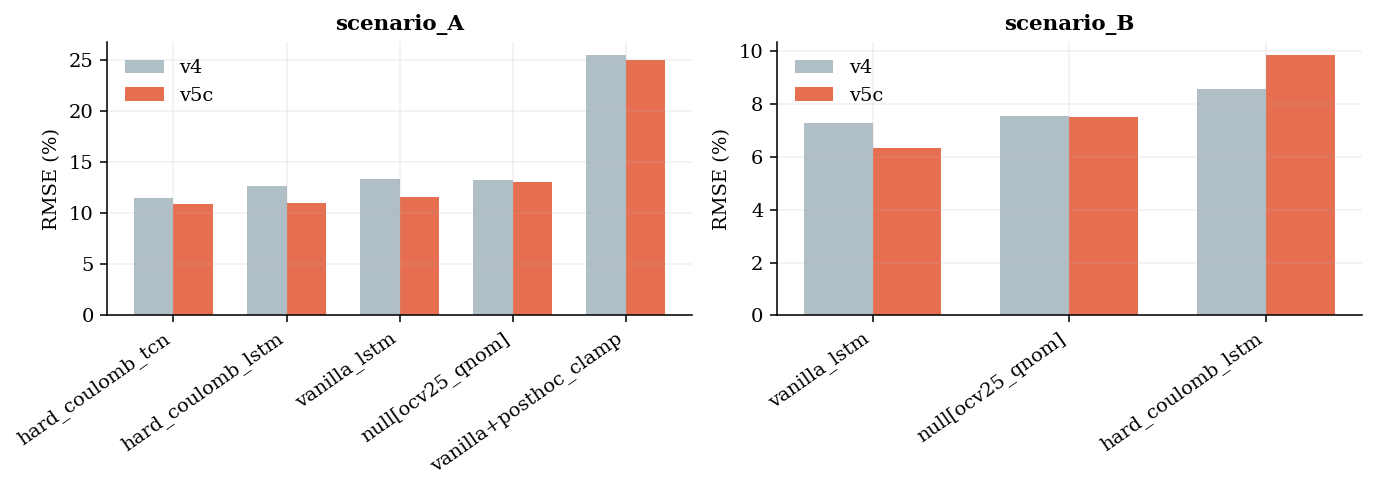

In [4]:
if not v4v5.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=False)
    for ax, scenario in zip(axes, ["scenario_A", "scenario_B"]):
        df = v4v5[v4v5["scenario"] == scenario]
        if df.empty:
            ax.set_visible(False); continue
        x = np.arange(len(df)); w = 0.35
        ax.bar(x - w/2, df["v4_rmse_pct"], width=w, label="v4", color=BASELINE_COLOR)
        ax.bar(x + w/2, df["v5c_rmse_pct"], width=w, label="v5c", color=OUR_COLOR)
        ax.set_xticks(x); ax.set_xticklabels(df["model"], rotation=35, ha="right")
        ax.set_title(scenario); ax.set_ylabel("RMSE (%)"); ax.legend()
    plt.tight_layout(); plt.show()


### MaxE artifact reduction

,model,scenario,v4_maxe_pct,v5c_maxe_pct,maxe_delta_pp
0,hard_coulomb_tcn,scenario_A,46.7303,43.2938,-3.4365
1,hard_coulomb_lstm,scenario_A,55.1126,46.1952,-8.9174
2,vanilla_lstm,scenario_A,51.0242,46.8817,-4.1425
3,null[ocv25_qnom],scenario_A,86.9666,60.9376,-26.0290
4,vanilla+posthoc_clamp,scenario_A,NaN,46.8818,NaN
5,vanilla_lstm,scenario_B,NaN,50.6370,NaN
6,null[ocv25_qnom],scenario_B,NaN,94.7159,NaN
7,hard_coulomb_lstm,scenario_B,34.9985,35.3573,0.3588


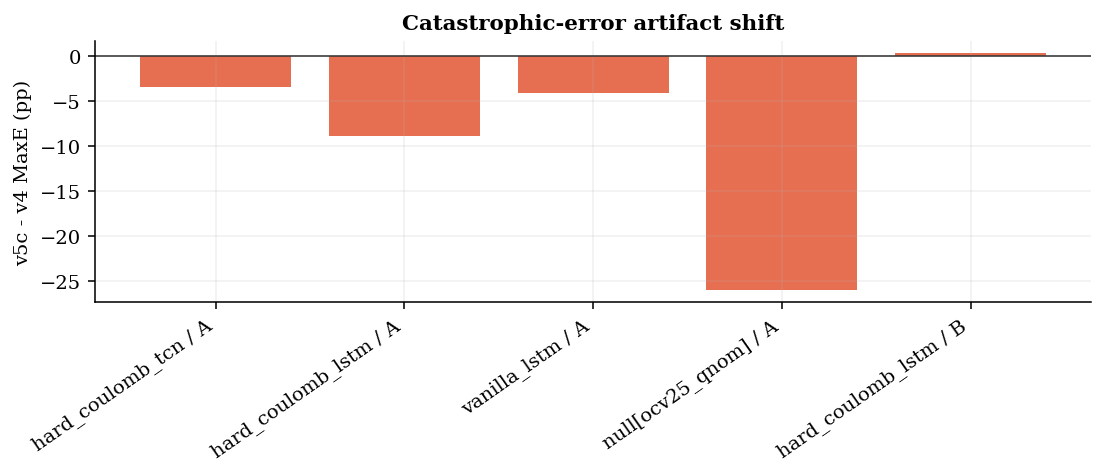

In [5]:
if not v4v5.empty:
    maxe = v4v5[["model","scenario","v4_maxe_pct","v5c_maxe_pct"]].dropna(subset=["v4_maxe_pct","v5c_maxe_pct"], how="all").copy()
    maxe["maxe_delta_pp"] = maxe["v5c_maxe_pct"] - maxe["v4_maxe_pct"]
    display(Markdown("### MaxE artifact reduction"))
    display(maxe.round(4))
    plot = maxe.dropna(subset=["maxe_delta_pp"])
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.bar(plot["model"] + " / " + plot["scenario"].str.replace("scenario_", ""), plot["maxe_delta_pp"], color=[OUR_COLOR if v < 0 else COLORS[4] for v in plot["maxe_delta_pp"]])
    ax.axhline(0, color="#333", linewidth=0.8)
    ax.set_ylabel("v5c - v4 MaxE (pp)")
    ax.set_title("Catastrophic-error artifact shift")
    plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()


In [6]:
if not final.empty:
    excerpt = final[final["model"].isin(["hc_anchor_last","hard_coulomb_lstm","vanilla_lstm","null[ocv25_qnom]"])]
    display(Markdown("### Final v5 model comparison excerpt"))
    display(excerpt[["scenario","model","anchor_strategy","inference_policy","rmse_pct","rmse_std","maxe_pct","rmse_n20","pvr_disch_eps0","source"]].round(4))


### Final v5 model comparison excerpt

,scenario,model,anchor_strategy,inference_policy,rmse_pct,rmse_std,maxe_pct,rmse_n20,pvr_disch_eps0,source
0,scenario_A,hard_coulomb_lstm,first,windowed,10.8740,0.1904,46.4673,16.3274,0.0000,multiseed/seed_level_results.csv
2,scenario_A,hc_anchor_last,last,windowed,9.9930,1.0897,36.4976,15.0454,0.0000,multiseed/seed_level_results.csv
4,scenario_A,vanilla_lstm,NaN,windowed,11.3474,0.1798,47.4796,17.2103,45.8981,multiseed/seed_level_results.csv
5,scenario_B,hard_coulomb_lstm,first,windowed,10.6291,0.5982,35.5544,7.7697,0.0000,multiseed/seed_level_results.csv
7,scenario_B,hc_anchor_last,last,windowed,4.7432,0.3141,34.4872,8.0530,0.0000,multiseed/seed_level_results.csv
9,scenario_B,vanilla_lstm,NaN,windowed,6.1997,0.2718,50.8375,8.6908,37.2987,multiseed/seed_level_results.csv
10,scenario_A,null[ocv25_qnom],NaN,windowed,13.0297,NaN,60.9376,19.5747,0.0000,baselines/deterministic_baselines_v5c.json
14,scenario_B,null[ocv25_qnom],NaN,windowed,7.5278,NaN,94.7159,14.3190,0.0000,baselines/deterministic_baselines_v5c.json
18,scenario_A,hard_coulomb_lstm,first,windowed_independent,11.0486,NaN,46.1873,16.7544,0.0000,recursive_inference/recursive_policy_results.json
19,scenario_A,hard_coulomb_lstm,first,carried_anchor,11.7799,NaN,29.6282,11.1109,0.0000,recursive_inference/recursive_policy_results.json


## Interpretation

v5 reduces artifact-driven catastrophic errors while making the final OOD contribution sharper: anchor design and inference policy become the main story, not stale label artifacts.

## Reviewer-risk note

Do not compare v4 and v5 as the same target distribution. Present v4 as legacy evidence and v5c as the corrected final ledger.

## Final conclusion

Corrected labels reduced artifact-driven catastrophic errors while strengthening the Hard-Coulomb contribution OOD.


In [7]:
show_missing()


### Missing artifacts recorded by this notebook: none